In [73]:
import yfinance as yf 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [74]:
tickers = ['AAPL', 'MSFT', 'JPM', 'XOM', 'GLD']
print(tickers)

['AAPL', 'MSFT', 'JPM', 'XOM', 'GLD']


In [75]:
prices=yf.download(tickers, start='2021-01-01', end='2026-01-01', auto_adjust=True)

[*********************100%***********************]  5 of 5 completed


In [76]:
close_prices = prices['Close']
returns = close_prices.pct_change().dropna()
returns.head()

Ticker,AAPL,GLD,JPM,MSFT,XOM
Date,,,,,
2021-01-05,0.012364,0.002962,0.005441,0.000965,0.048193
2021-01-06,-0.033662,-0.016241,0.046956,-0.025929,0.025517
2021-01-07,0.034123,-0.002335,0.032839,0.028457,0.007846
2021-01-08,0.008631,-0.034210,0.001104,0.006093,0.011121
2021-01-11,-0.023249,-0.001961,0.014924,-0.009698,0.030356


In [77]:
correlation_matrix = returns.corr()
correlation_matrix

Ticker,AAPL,GLD,JPM,MSFT,XOM
Ticker,,,,,
AAPL,1.000000,0.071100,0.345422,0.633958,0.189419
GLD,0.071100,1.000000,0.012929,0.071022,0.140198
JPM,0.345422,0.012929,1.000000,0.311269,0.363756
MSFT,0.633958,0.071022,0.311269,1.000000,0.084765
XOM,0.189419,0.140198,0.363756,0.084765,1.000000


Text(0.5, 1.0, 'Correlation Matrix of Daily Returns')

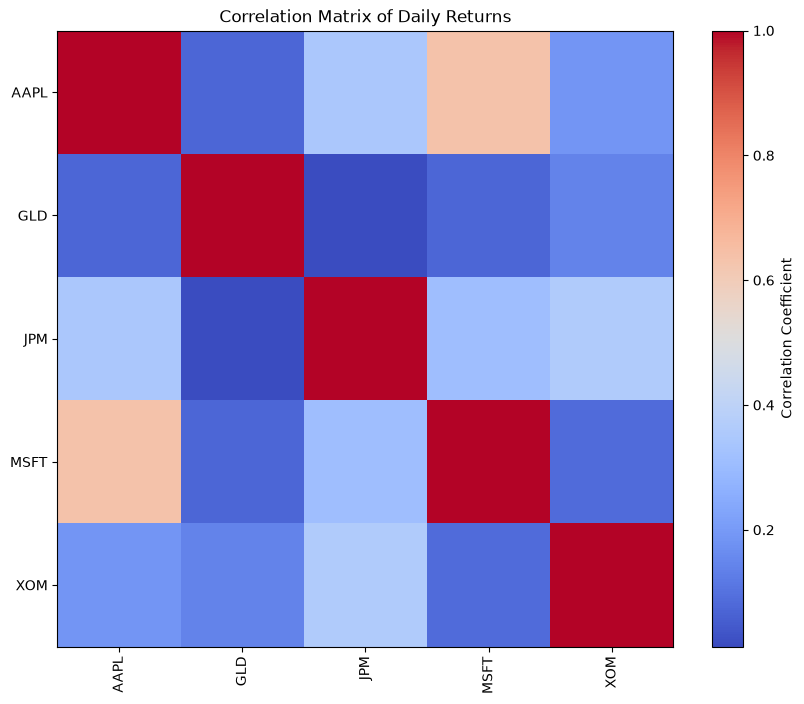

In [78]:
plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(correlation_matrix)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix)), correlation_matrix.index)
plt.title('Correlation Matrix of Daily Returns')

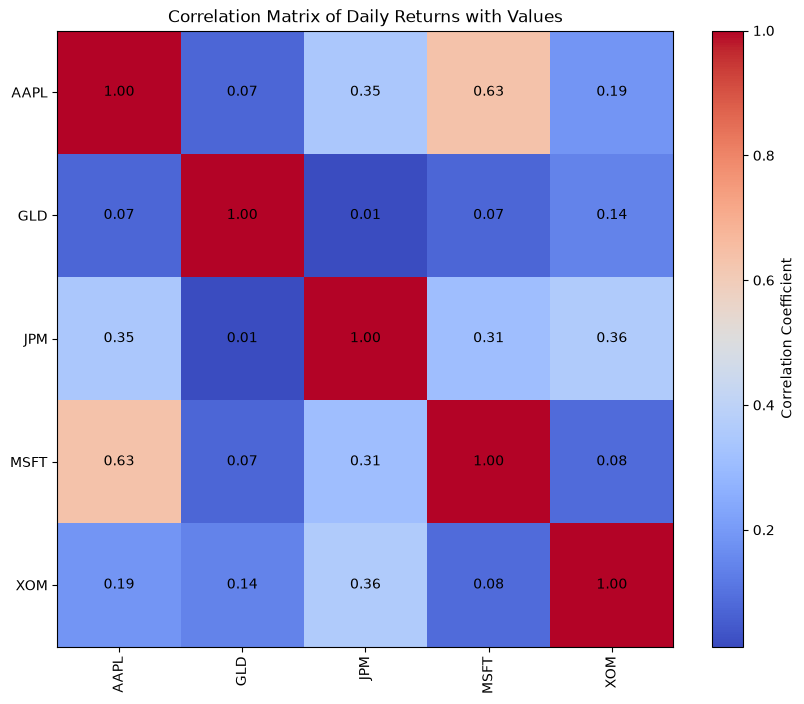

In [79]:
plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(correlation_matrix)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix)), correlation_matrix.index)

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}", ha='center', va='center')
plt.title('Correlation Matrix of Daily Returns with Values')
plt.show()

In [80]:
covariance_matrix = returns.cov()
covariance_matrix

Ticker,AAPL,GLD,JPM,MSFT,XOM
Ticker,,,,,
AAPL,0.000308,0.000012,0.000093,0.000180,0.000057
GLD,0.000012,0.000097,0.000002,0.000011,0.000023
JPM,0.000093,0.000002,0.000234,0.000077,0.000095
MSFT,0.000180,0.000011,0.000077,0.000262,0.000023
XOM,0.000057,0.000023,0.000095,0.000023,0.000290


In [81]:
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])  # Equal weights for each asset
portfolio_returns=returns @ weights

In [82]:
portfolio_returns.head()

Date
2021-01-05    0.013985
2021-01-06   -0.000672
2021-01-07    0.020186
2021-01-08   -0.001452
2021-01-11    0.002074
dtype: float64

In [83]:
portfolio_returns.describe()

count    1254.000000
mean        0.000872
std         0.009671
min        -0.055728
25%        -0.004023
50%         0.001109
75%         0.006144
max         0.084417
dtype: float64

In [84]:
portfolio_daily_volatility = portfolio_returns.std()
portfolio_daily_volatility

np.float64(0.009671187833215194)

In [85]:
portfolio_annualized_volatility = portfolio_daily_volatility * np.sqrt(252)
portfolio_annualized_volatility

np.float64(0.15352534733568612)

In [86]:
portfolio_variance=weights.T @ covariance_matrix @ weights
portfolio_volatility_covariance=np.sqrt(portfolio_variance)
portfolio_volatility_covariance

np.float64(0.009671187833215194)

In [87]:
marginal_contribution=covariance_matrix @ weights
marginal_contribution

Ticker
AAPL    0.000130
GLD     0.000029
JPM     0.000100
MSFT    0.000111
XOM     0.000098
dtype: float64

In [88]:
risk_contribution=weights * marginal_contribution
risk_contribution

Ticker
AAPL    0.000026
GLD     0.000006
JPM     0.000020
MSFT    0.000022
XOM     0.000020
dtype: float64

In [89]:
risk_contribution_pct=risk_contribution / risk_contribution.sum()
risk_contribution_pct

Ticker
AAPL    0.277933
GLD     0.062343
JPM     0.213950
MSFT    0.237107
XOM     0.208667
dtype: float64

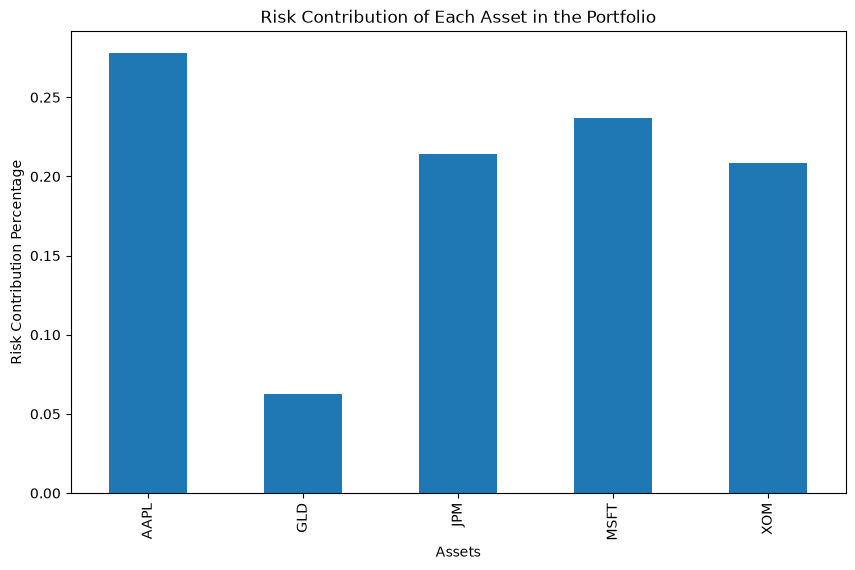

In [90]:
risk_contribution_pct.plot(kind='bar', figsize=(10, 6))
plt.title('Risk Contribution of Each Asset in the Portfolio')
plt.xlabel('Assets')
plt.ylabel('Risk Contribution Percentage')
plt.show()

##Observations

<Correlation>

- AAPL and MSFT had the strongest correlation in the portfolio with a correlation of apprximately 0.63. This indicates a relatively strong linear relationship between their daily returns.

- GLD had a very low correlation with the other assets, especially JPM with a correlation of approximately 0.1.

- All pairwise correlations were positive meaning that none of the assets displayed a consistently negative relationship over the period.

- The relatively low correlations between GLD and the equity assets would indicate that GLD could provide diversification benefits within the protfolio.

<Portfolio Risk>

- An equal weight portfolio was constructed, allocating 20% to each asset.
- Portfolio volatility was calculated both directly from the portfolio's historical returns and through the covariance matrix. The two ways produced approximately the same result showing consistency check.
- The covariance matrix demonstrates that protfolio risk not only depends on the individual volatility of each asset but also on the relationship between assets.

<Risk Contribution>

- Although each asset has an equal 20% portfolio weight, the assets do not necessarily contribute equally to overall portfolio risk.
- Differences in individual volatility and correlations cause some assets to contribute more to portfolio risk than others.
- This demonstrates an equal weight portfolio is not necessarily an equal risk portfolio.

<Overall Observation>
The analysis demonstrates the importance of diversification in portfolio construction.
Assets with lower correlation can reduce the interaction between sources of risk, while highly correlated assets can cause risks to reinforce each other. The results provide the basis for the next stage, where portfolio risk will be assessed using value at risk (VaR) and expected shortfall.
